In [1]:
from ase.io import read, write
from ase import units
import matplotlib.pyplot as plt
import numpy as np
from imolcryff.trainer.dmff_utils import merge_xml
from imolcryff.trainer import DistanceTrainer
from imolcryff.calculator.distance import DistanceCalculator
from imolcryff.io.rdkit import atoms2rdkit
from imolcryff.crafter.asemol import aseatoms2pdb, asemol_wrapper, merge_asemols
import os

/Users/srak/apl/iMolCRAFT/DMFF/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:
atoms_snli = read("SNLi.log")

In [3]:
merge_xml(["SN.xml", "Li.xml"], "merged.xml")

'xmlfiles/merged.xml'

In [4]:
calculator = DistanceCalculator(
    atoms_snli,
    1,
    "cn__Li",
    scan_idx=[[5,10]],
    directory="distance_scan",
    qmparams={
             "method": "wb97xd",
             "basis": "6-31g(d)",
             "opt": "modredundant",
             }
)

In [5]:
import glob

g16logs = glob.glob("distance_scan/*.log")

for i, g16log in enumerate(g16logs):
    atoms = read(g16log)
    distance = atoms.get_distance(5, 10)
    energy = atoms.get_potential_energy()/(units.kJ / units.mol)
    calculator.qm_distancescan[0]["distances_A"].append(distance)
    calculator.qm_distancescan[0]["energy_kjmol"].append(energy)
    calculator.qm_distancescan[0]["atoms"].append(atoms)

In [6]:
# calculator.qm_distancescan[0]でcalculator.qm_distancescan[0]["distances_A"]ベースでソート
# "distances_A"の値で全リストをソート
order = np.argsort(calculator.qm_distancescan[0]["distances_A"])
for key in calculator.qm_distancescan[0]:
	calculator.qm_distancescan[0][key] = [calculator.qm_distancescan[0][key][i] for i in order]
# calculator.qm_distancescan[0]

In [7]:
calculator.do_ffscan("xmlfiles/merged.xml")

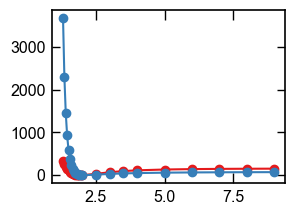

In [8]:
plt.plot(calculator.qm_distancescan[0]["distances_A"], np.array(calculator.qm_distancescan[0]["energy_kjmol"])-min(calculator.qm_distancescan[0]["energy_kjmol"]), marker="o")
plt.plot(calculator.ff_distancescan[0]["distances_A"], np.array(calculator.ff_distancescan[0]["energy_kjmol"])-min(calculator.ff_distancescan[0]["energy_kjmol"]), marker="o")

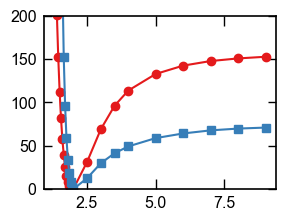

In [9]:
plt.ylim(0,200)
plt.plot(calculator.qm_distancescan[0]["distances_A"], np.array(calculator.qm_distancescan[0]["energy_kjmol"])-min(calculator.qm_distancescan[0]["energy_kjmol"]), marker="o")
plt.plot(calculator.ff_distancescan[0]["distances_A"], np.array(calculator.ff_distancescan[0]["energy_kjmol"])-min(calculator.ff_distancescan[0]["energy_kjmol"]), marker="s")

In [10]:
dtrainer = DistanceTrainer(ffxml_list=["SN.xml", "Li.xml"], 
                           nums_ffxml=[1,1], 
                           pdb="check.pdb", 
                           calculator=calculator, 
                           optparam_types=["NonbondedForce/charges", "VsiteForce/weight"],
                           lr=0.002)

In [11]:
# dtrainer.setup(trainer_checkpoint="train_state-12000.pkl")
dtrainer.setup()

In [12]:
dtrainer.ffparams

{'HarmonicBondForce': {'length': Array([0.1153, 0.1467, 0.1538, 0.1097], dtype=float64),
  'k': Array([746040.672, 247575.648, 194572.736, 314569.856], dtype=float64)},
 'HarmonicAngleForce': {'angle': Array([3.11680898, 1.94970731, 1.90956473, 1.91637152, 1.87762521],      dtype=float64),
  'k': Array([612.671488, 554.597568, 409.019472, 391.756288, 326.01728 ],      dtype=float64)},
 'PeriodicTorsionForce': {'proper_phase': Array([3.14159265, 3.14159265, 0.        , 0.        , 0.        ],      dtype=float64),
  'proper_k': Array([0.        , 0.        , 0.65084444, 0.65084444, 0.50208   ],      dtype=float64),
  'improper_phase': Array([], shape=(0,), dtype=float64),
  'improper_k': Array([], shape=(0,), dtype=float64)},
 'NonbondedForce': {'sigma': Array([0.32735182, 0.34789595, 0.33977095, 0.2600177 , 0.1       ,
         0.20259037], dtype=float64),
  'epsilon': Array([0.4594032, 0.6677664, 0.4510352, 0.0870272, 0.       , 0.0765672],      dtype=float64),
  'charges': Array([-0.

In [13]:
from imolcryff.trainer.dmff_utils import neutralize

def add_mask_fn(grads):
    # N --- 8,9,10,11
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[0].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[1].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[2].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[3].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[4].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[5].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[6].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[7].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[8].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[9].set(0.0)
    grads["NonbondedForce"]["charges"] = grads["NonbondedForce"]["charges"].at[12].set(0.0)
    return grads

def ffparams_modify(ffparams):
    ffparams = neutralize(ffparams, dtrainer.natoms_list, nc=0.8,
                         target_lists=[[0,5,10,11]], # N+VS charges
                         target_charges=[-0.8901744])

    sum_1 = ffparams["VsiteForce"]["weight"][0] + ffparams["VsiteForce"]["weight"][2]
    sum_2 = ffparams["VsiteForce"]["weight"][1] + ffparams["VsiteForce"]["weight"][3]

    diff = (2 - (sum_1 + sum_2))/4
    ffparams["VsiteForce"]["weight"] = ffparams["VsiteForce"]["weight"].at[0].set(sum_1/2 + diff)
    ffparams["VsiteForce"]["weight"] = ffparams["VsiteForce"]["weight"].at[1].set(sum_2/2 + diff)
    ffparams["VsiteForce"]["weight"] = ffparams["VsiteForce"]["weight"].at[2].set(sum_1/2 + diff)
    ffparams["VsiteForce"]["weight"] = ffparams["VsiteForce"]["weight"].at[3].set(sum_2/2 + diff)

    return ffparams

In [ ]:
dtrainer.fit(steps=20000, relax_steps=1000, add_mask_fn=add_mask_fn, ffparams_modify=ffparams_modify)
# dtrainer.fit(steps=200, relax_steps=100, add_mask_fn=add_mask_fn, ffparams_modify=ffparams_modify)

Time taken for epoch 0: 8.98 seconds
epoch 0
loss 12211.556063603048, best loss 12211.556063603048 at epoch 0
Time taken for epoch 1: 0.12 seconds
Time taken for epoch 2: 0.12 seconds
Time taken for epoch 3: 0.11 seconds
Time taken for epoch 4: 0.12 seconds
Time taken for epoch 5: 0.11 seconds
Time taken for epoch 6: 0.11 seconds
Time taken for epoch 7: 0.21 seconds
Time taken for epoch 8: 0.12 seconds
Time taken for epoch 9: 0.12 seconds
Time taken for epoch 10: 0.11 seconds
Time taken for epoch 11: 0.11 seconds
Time taken for epoch 12: 0.11 seconds
Time taken for epoch 13: 0.11 seconds
Time taken for epoch 14: 0.11 seconds
Time taken for epoch 15: 0.11 seconds
Time taken for epoch 16: 0.11 seconds
Time taken for epoch 17: 0.11 seconds
Time taken for epoch 18: 0.11 seconds
Time taken for epoch 19: 0.11 seconds
Time taken for epoch 20: 0.11 seconds
Time taken for epoch 21: 0.11 seconds
Time taken for epoch 22: 0.11 seconds
Time taken for epoch 23: 0.12 seconds
Time taken for epoch 24: 

In [15]:
dtrainer.losses

[Array(12211.5560636, dtype=float64),
 Array(10147.54328567, dtype=float64),
 Array(7086.38609859, dtype=float64)]

In [16]:
dtrainer.epochs

[0, 100, 200]

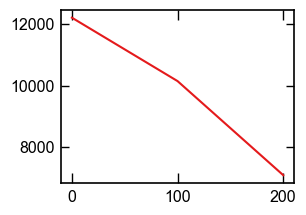

In [17]:
plt.plot(dtrainer.epochs, dtrainer.losses)

In [18]:
idx = np.argmin(dtrainer.losses)
print(dtrainer.epochs[idx], dtrainer.losses[idx])

200 7086.3860985916035


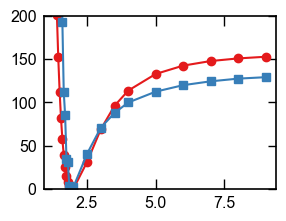

In [24]:
plt.ylim(0,200)
plt.plot(calculator.qm_distancescan[0]["distances_A"], np.array(calculator.qm_distancescan[0]["energy_kjmol"])-min(calculator.qm_distancescan[0]["energy_kjmol"]), marker="o")
plt.plot(dtrainer.calculator.ff_distancescan[0]["distances_A"], np.array(dtrainer.calculator.ff_distancescan[0]["energy_kjmol"])-min(dtrainer.calculator.ff_distancescan[0]["energy_kjmol"]), marker="s")